# 03 - Validation of the Model

The goal of this notebook is to validate the model created. Before introducing the tournament mechanics with match simulations, we must first ensure that what we built reflects the reality of the ATP tour.

Here, we simulate the life cycle of tennis players over a certain period using the calibrated parameters from the `simulation_params.json` file: we generate a number of new players (18 y.o.) entering the circuit each year, by drawing a potential for each of them based on the calibrated distributions. We then apply the modeled aging curve with random fluctuations to update each player's relative strength. Finally, we also simulate career end usning te probability law based on age.

From these synthetic data, we can compare them directly against the observed ATP data, by validating the stability of the number of active players per year, and the evolution of the career profiles (start age, retirement, top strength,...).

In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing the parameters stored in the .json file
import json

config_path = "../config/simulation_params.json"

with open(config_path, "r") as f:
    config_params = json.load(f)

In [3]:
# for autoreload the modifications of the functions in the simulation.py file
%load_ext autoreload
%autoreload 2

In [4]:
# import the functio for simulations (from the simulation.py file in the src.)
from simulation import run_simulation

## 1. Validation of the Stability of Number of New Players per Year
We run the simulation over a long period of years. The initial years correspond to the "warm-up" phase to allow the system to stabilise (let the first generation age and retire). The goal is to compare the number of active players per year from the synthetic data and the observed ones, and to check whether the number of players doesn't fall to 0 or keeps increasing.

In [5]:
start_year = 0
end_year = 100

In [23]:
# 1. Run Simulation
# e.g. from 1950 to 2024 (to have a "warm-up" phase and wait for the data to stabilize)
global_simulation = run_simulation(start_year=start_year, end_year=end_year, 
                                            config_params=config_params,
                                            aging_model_choice="global")
synthetic_active_players = global_simulation[global_simulation["is_active"] == True]
synthetic_active_per_year = synthetic_active_players.groupby("current_year").size()

# 2. Load Observed Results (Zermelo Strengths)
observed_strengths_path = "../data/processed/zermelo_strengths_1991-2024.csv"
observed_strengths = pd.read_csv(observed_strengths_path, low_memory=False)
observed_active_per_year = observed_strengths.groupby("year").size()

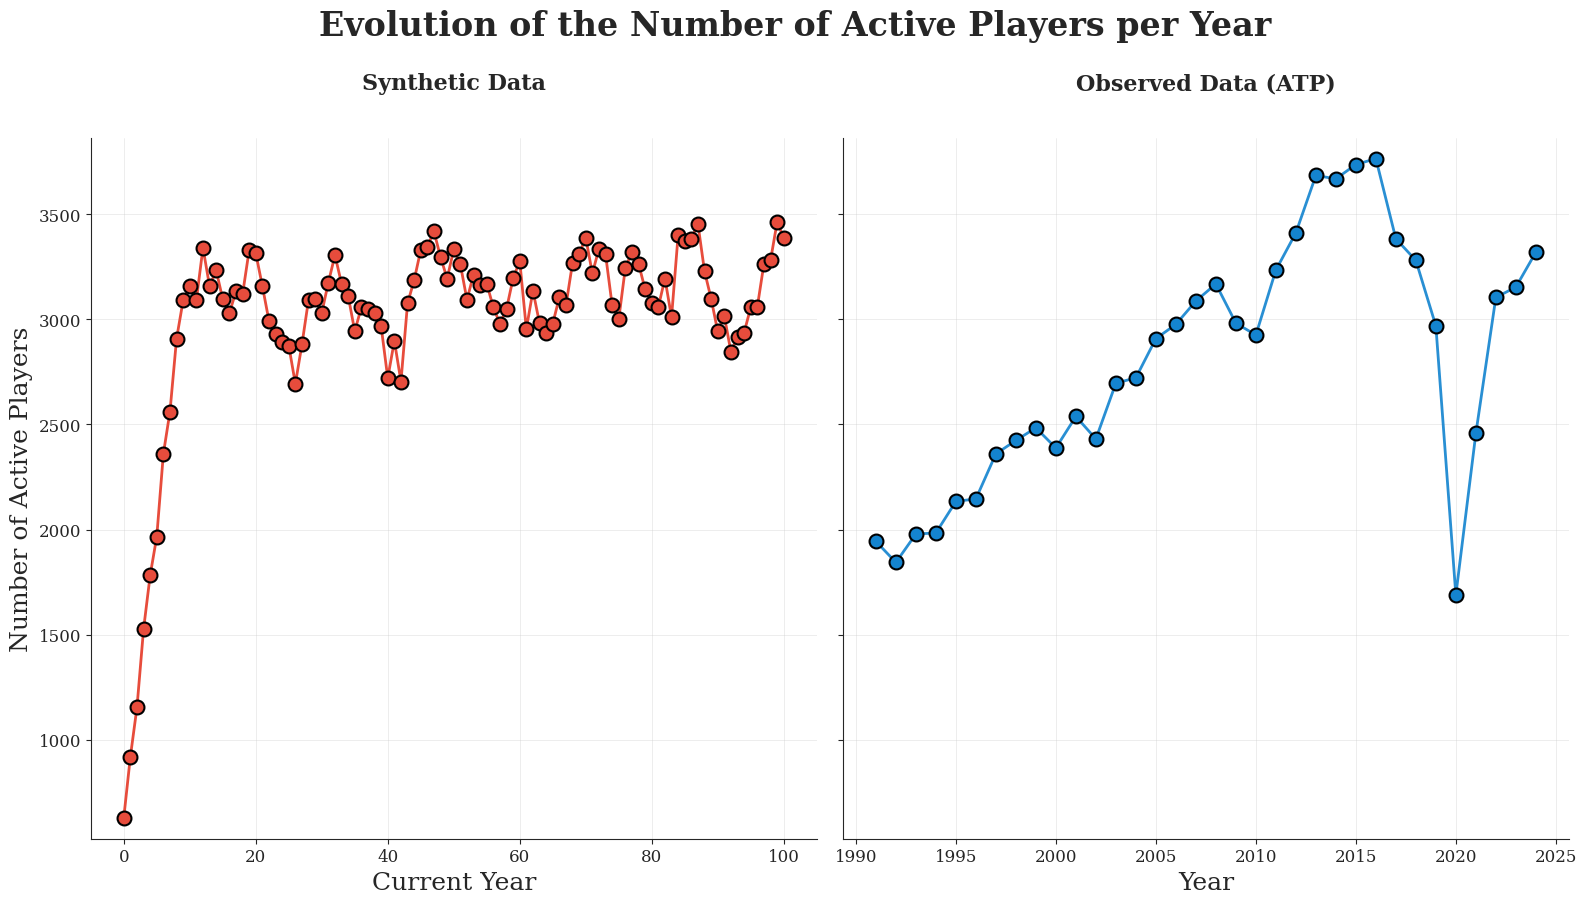

In [7]:
# Plot of the number of active players 

min_number_active = np.min([np.min(synthetic_active_per_year), np.min(observed_active_per_year)])
max_number_active = np.max([np.max(synthetic_active_per_year), np.max(observed_active_per_year)])


plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})


# Plot of the SYNTHETIC Number of Active Players per Year
plt.subplot(1,2,1)
sns.scatterplot(x=synthetic_active_per_year.index, y=synthetic_active_per_year.values, 
                    color="#e74c3c", edgecolor="black", 
                    linewidth=1.5, s=100, alpha=1, 
                    zorder=2)

plt.plot(synthetic_active_per_year.index, synthetic_active_per_year.values, color="#e74c3c", linewidth=2, zorder=1)

plt.title("Synthetic Data", fontsize=16, weight="bold", pad=35)
plt.xlabel("Current Year", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Number of Active Players", fontsize=18)
plt.ylim(min_number_active-100, max_number_active+100)
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)


# Plot of the OBSERVED Number of Active Players per Year
plt.subplot(1,2,2)
sns.scatterplot(x=observed_active_per_year.index, y=observed_active_per_year.values, 
                    color="#1484cfe8", edgecolor="black", 
                    linewidth=1.5, s=100, alpha=1, 
                    zorder=2)

plt.plot(observed_active_per_year.index, observed_active_per_year.values, color="#1484cfe8", linewidth=2, zorder=1)

plt.title("Observed Data (ATP)", fontsize=16, weight="bold", pad=35)
plt.xlabel("Year", fontsize=18)
plt.ylim(min_number_active-100, max_number_active+100)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(axis='y', labelleft=False)
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)

plt.suptitle("Evolution of the Number of Active Players per Year", fontsize=24, weight="bold", y=1.)   
sns.despine()
plt.tight_layout()
plt.show()

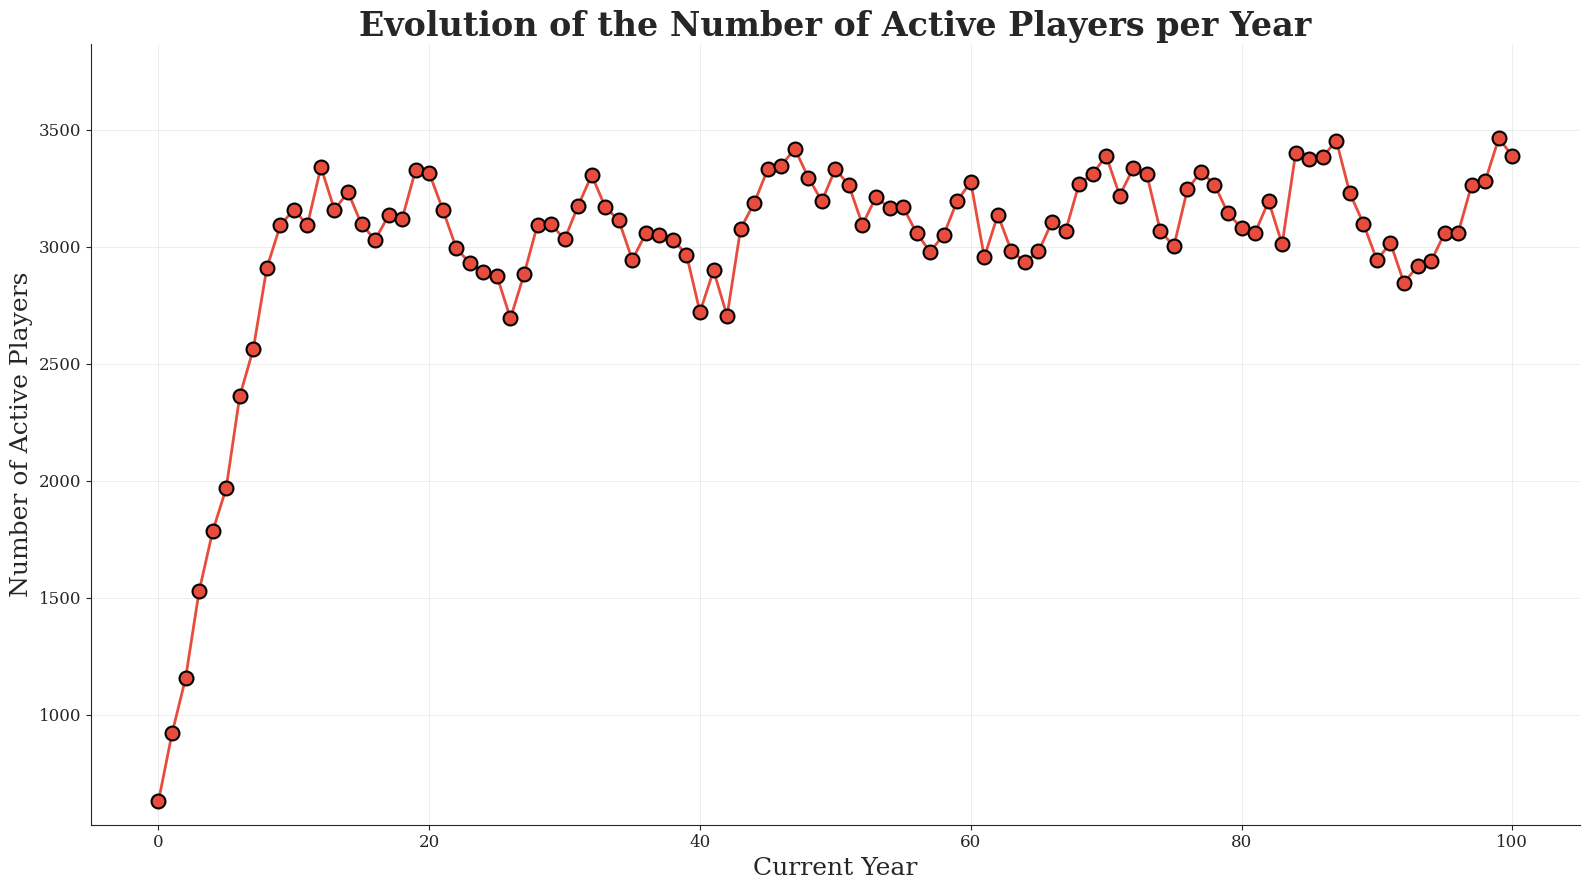

In [8]:
# Plot of the number of active players 

min_number_active = np.min([np.min(synthetic_active_per_year), np.min(observed_active_per_year)])
max_number_active = np.max([np.max(synthetic_active_per_year), np.max(observed_active_per_year)])


plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})


# Plot of the SYNTHETIC Number of Active Players per Year
sns.scatterplot(x=synthetic_active_per_year.index, y=synthetic_active_per_year.values, 
                    color="#e74c3c", edgecolor="black", 
                    linewidth=1.5, s=100, alpha=1, 
                    zorder=2)

plt.plot(synthetic_active_per_year.index, synthetic_active_per_year.values, color="#e74c3c", linewidth=2, zorder=1)

plt.title("Synthetic Data", fontsize=16, weight="bold", pad=35)
plt.xlabel("Current Year", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Number of Active Players", fontsize=18)
plt.ylim(min_number_active-100, max_number_active+100)
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)

plt.title("Evolution of the Number of Active Players per Year", fontsize=24, weight="bold", y=1.)   
sns.despine()
plt.tight_layout()
plt.show()

Good news here, as the number of players remains quite constant (no drop to 0 or increase to infinity). The number of players for the synthetic data is bigger, but this is expected as we considered the number of new players as constant, and the model doesn't take into account injuries (which would decrease the number of active players each year).

## 2. Validation of the Career Profiles
We now compare the start and end ages for both types of data, as well as the top strength (in log10). The danger here is that some players  (synthetic data) never reached their attributed potential, as they had to retire earlier, which could change the global distribution...

In [9]:
# function keeping only relevant columns from synthetic data that can be compared with the real data 
def get_synthetic_data(simulation_data):

    simulation_data_per_player = simulation_data.groupby("player_id")

    synthetic_data = simulation_data_per_player.agg({
        "age": ["min", "max"],
        "current_log10_strength": ["max"],
        "start_year": ["first"],
    })

    synthetic_data.columns = ["start_age", "end_age", "log10_top_strength", "start_year"]
    synthetic_data["end_age"] -= 1
    synthetic_data = synthetic_data.reset_index()

    return synthetic_data

In [10]:
# Apply the function to get the relevant columns
global_synthetic_data = get_synthetic_data(global_simulation)

# Remove the "warm_up" phase, and the last 10 years (to avoid right-censoring, as for the observed data)
global_synthetic_data_filtered = global_synthetic_data[(global_synthetic_data["start_year"]>=start_year+15) &
                                        (global_synthetic_data["start_year"]<=end_year-10)].copy()

# Load the observed career data (calibration players)
observed_data_path = "../data/processed/calibration_players_1992-2014.csv"
observed_data = pd.read_csv(observed_data_path, low_memory=False)
# display(observed_data)

### 2.1. End Ages Comparison
Here we aim to compare the distributions from both datasets for the ending age, to see whether the model reproduces well the retirement process.

In [11]:
global_synthetic_data_filtered["end_age"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

count    50291.000000
mean        22.728580
std          4.553142
min         15.000000
25%         19.000000
50%         22.000000
75%         25.000000
95%         31.000000
99%         35.000000
max         45.000000
Name: end_age, dtype: float64

In [12]:
observed_data["end_age"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

count    15679.000000
mean        23.466356
std          5.110041
min         14.000000
25%         19.000000
50%         23.000000
75%         26.000000
95%         33.000000
99%         38.000000
max         62.000000
Name: end_age, dtype: float64

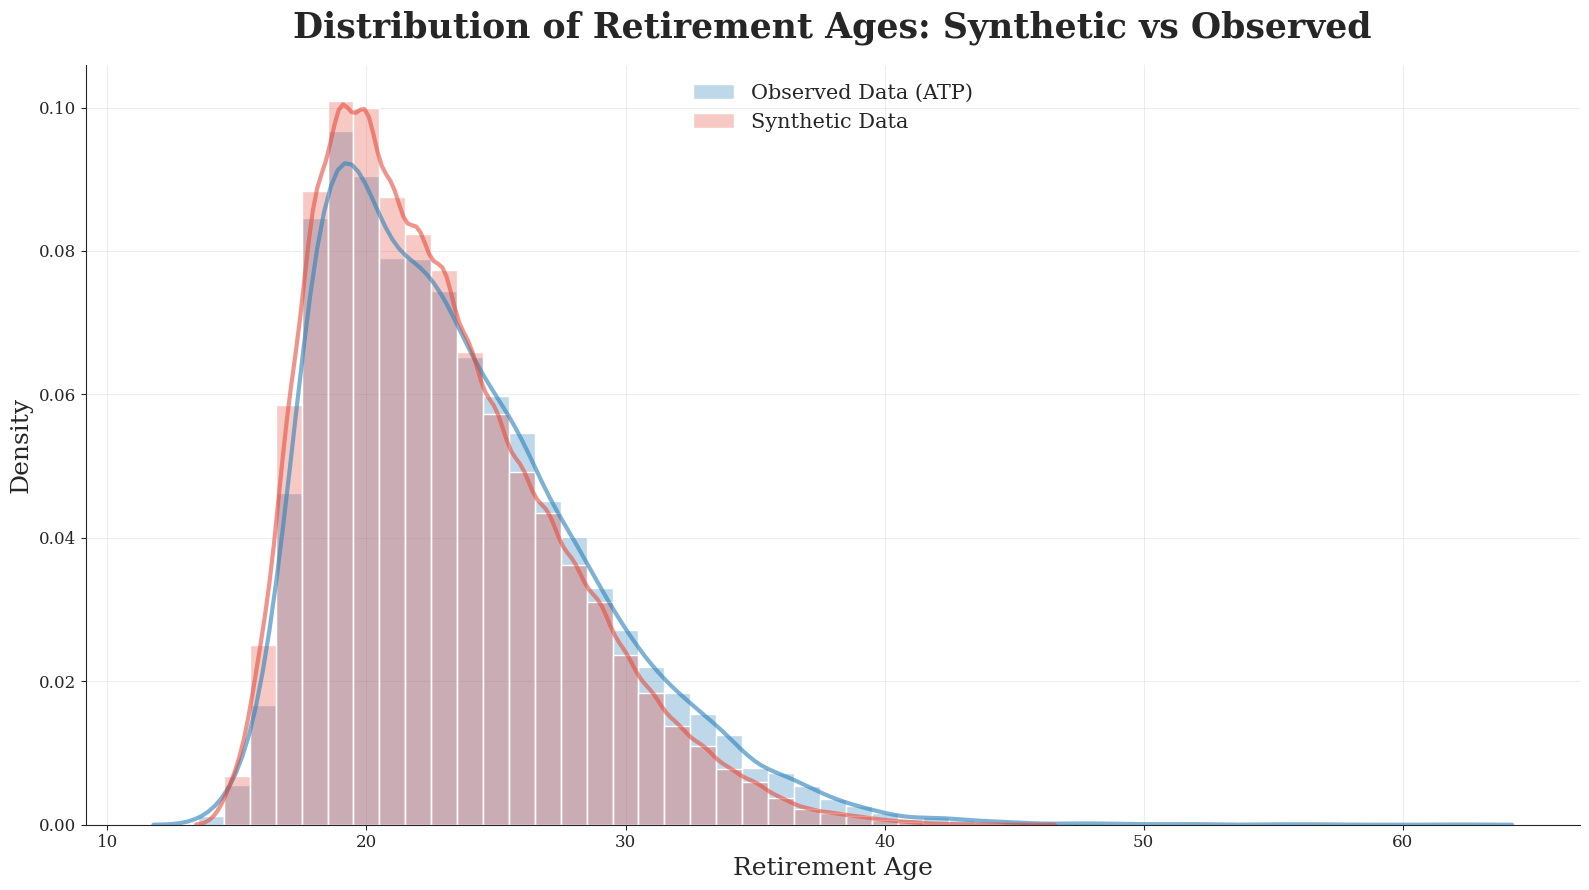

In [13]:
# Plot of the end ages histogram (comparison between observed and synthetic data)

plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})

# plot of the OBSERVED data
sns.histplot(data=observed_data, x="end_age",
            color="#2980b9",alpha=0.3, stat="density", 
            discrete=True, common_norm=False,
            zorder=1, label="Observed Data (ATP)")

sns.kdeplot(data=observed_data, x="end_age", 
            color = "#2980b9", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)

# plot of the SYNTHETIC data
sns.histplot(data=global_synthetic_data_filtered, x="end_age",
            color="#e74c3c",alpha=0.3, stat="density", 
            discrete=True, common_norm=False,
            zorder=1, label="Synthetic Data")

sns.kdeplot(data=global_synthetic_data_filtered, x="end_age", 
            color = "#e74c3c", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)


plt.title("Distribution of Retirement Ages: Synthetic vs Observed", fontsize=25, weight="bold", pad=20)
plt.xlabel("Retirement Age", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(frameon=False, fontsize=15, loc="upper center")
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

Thanks to the realistic start age distribution, the model is able to reproduce a realistic end age distribution, with the same shape.

### 2.2. Top Strength Achieved Comparison

In [14]:
global_synthetic_data_filtered["log10_top_strength"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    50291.000000
mean        -0.290498
std          0.385893
min         -1.696837
25%         -0.538978
50%         -0.345032
75%         -0.144425
95%          0.501416
max          1.855733
Name: log10_top_strength, dtype: float64

In [15]:
observed_data["log10_top_strength"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    15679.000000
mean        -0.215585
std          0.347195
min         -1.431388
25%         -0.420682
50%         -0.279321
75%         -0.097277
95%          0.501927
max          2.468258
Name: log10_top_strength, dtype: float64

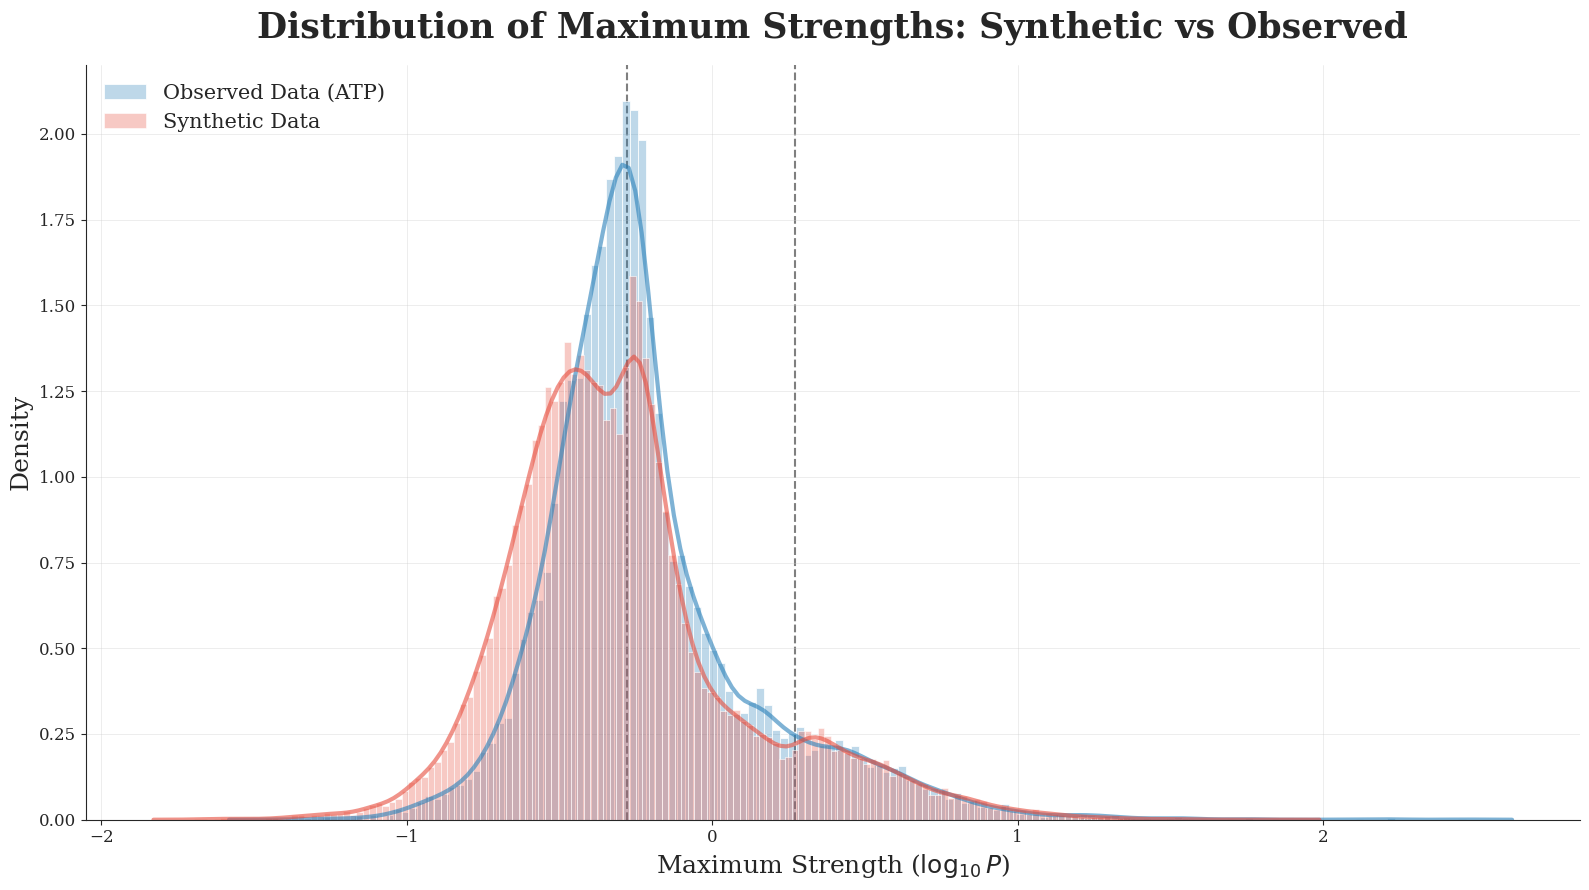

In [16]:
# Plot of the end ages histogram (comparison between observed and synthetic data)

plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})

# plot of the OBSERVED data
sns.histplot(data=observed_data, x="log10_top_strength",
            color="#2980b9",alpha=0.3, stat="density", 
            bins="auto", common_norm=False,
            zorder=1, label="Observed Data (ATP)")

sns.kdeplot(data=observed_data, x="log10_top_strength", 
            color = "#2980b9", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)

# plot of the SYNTHETIC data
sns.histplot(data=global_synthetic_data_filtered, x="log10_top_strength",
            color="#e74c3c",alpha=0.3, stat="density", 
            bins="auto", common_norm=False,
            zorder=1, label="Synthetic Data")

sns.kdeplot(data=global_synthetic_data_filtered, x="log10_top_strength", 
            color = "#e74c3c", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)


plt.title("Distribution of Maximum Strengths: Synthetic vs Observed", fontsize=25, weight="bold", pad=20)
plt.xlabel(r"Maximum Strength ($\log_{10} P$)", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.axvline(-0.28, linestyle="--", alpha=0.5, color="black", zorder=0)
plt.axvline(0.27, linestyle="--", alpha=0.5, color="black", zorder=0)


plt.legend(frameon=False, fontsize=15, loc="upper left")
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

The vertical lines stratify the players into the three different groups. We see that the synthetic distribution for the top players is well aligned with the theoretical data. However, the two other categories of players (middle and bottom) do not fit really well. This can be explained by the fact that the maximum strength assigned to each player can be reached only if the player is still active at age 27-28. For these kind of players, the retirement process implies that they do not play many years and do not reach their maximum strength. For this reason, the data are translated to the left and it doesn't match the ATP data anymore.

To fix this, the idea is to have an aging curve per category of players. I had to go back to the second notebook (02_Calibration) to stratify the players for the aging curves. Now, there is an additional argument in the function to choose whether you use a global model (1 curve for everyone) or stratified model (3 different curves depending on the player's potential).

In [17]:
stratified_simulation = run_simulation(start_year=start_year, end_year=end_year, 
                                            config_params=config_params,
                                            aging_model_choice="stratified")

In [18]:
stratified_synthetic_data = get_synthetic_data(stratified_simulation)
 
#Remove the "warm_up" phase, and the last 10 years (to avoid right-censoring, as for the observed data)
stratified_synthetic_data_filtered = stratified_synthetic_data[(stratified_synthetic_data["start_year"]>=start_year+15) &
                                        (stratified_synthetic_data["start_year"]<=end_year-10)].copy()

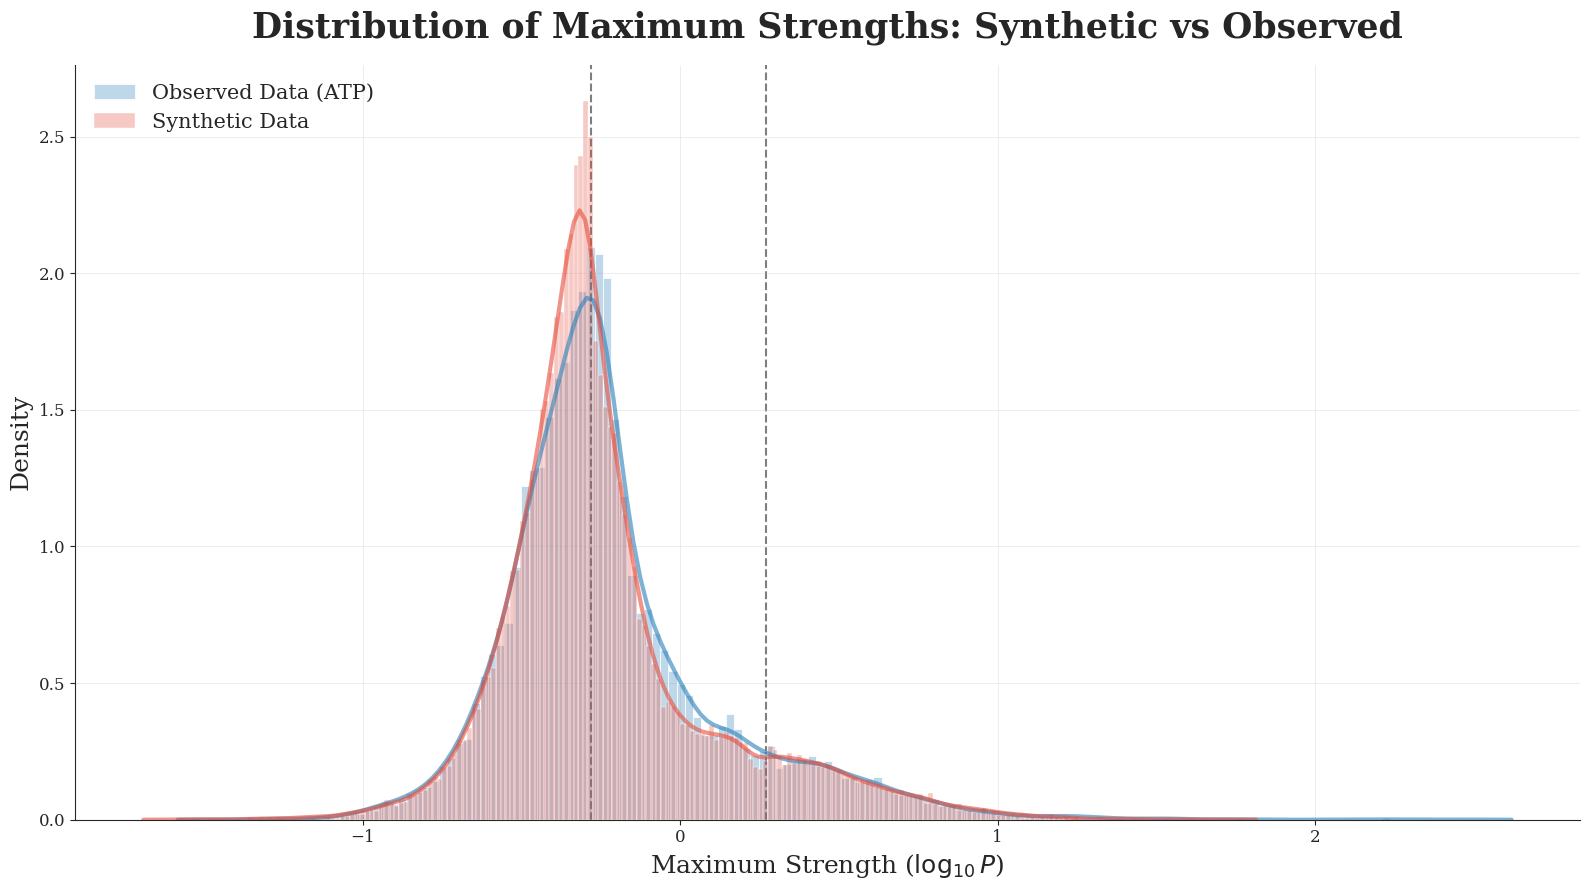

In [19]:
# Plot of the end ages histogram (comparison between observed and synthetic data)

plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})

# plot of the OBSERVED data
sns.histplot(data=observed_data, x="log10_top_strength",
            color="#2980b9",alpha=0.3, stat="density", 
            bins="auto", common_norm=False,
            zorder=1, label="Observed Data (ATP)")

sns.kdeplot(data=observed_data, x="log10_top_strength", 
            color = "#2980b9", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)

# plot of the SYNTHETIC data
sns.histplot(data=stratified_synthetic_data_filtered, x="log10_top_strength",
            color="#e74c3c",alpha=0.3, stat="density", 
            bins="auto", common_norm=False,
            zorder=1, label="Synthetic Data")

sns.kdeplot(data=stratified_synthetic_data_filtered, x="log10_top_strength", 
            color = "#e74c3c", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)


plt.title("Distribution of Maximum Strengths: Synthetic vs Observed", fontsize=25, weight="bold", pad=20)
plt.xlabel(r"Maximum Strength ($\log_{10} P$)", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.axvline(-0.28, linestyle="--", alpha=0.5, color="black", zorder=0)
plt.axvline(0.27, linestyle="--", alpha=0.5, color="black", zorder=0)


plt.legend(frameon=False, fontsize=15, loc="upper left")
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

The result is now perfectly aligned with the observed data!

### 2.3. Strength Median Value for each age and Category

In [20]:
# get a DataFrame with the current strength and the associated age
observed_data_ages = observed_data[["player_id", "start_year", "start_age", "log10_top_strength"]].copy()
observed_strengths_with_age = pd.merge(observed_strengths, observed_data_ages, on="player_id", how="inner")

# current age = year - start year + start age
observed_strengths_with_age["age"] = observed_strengths_with_age["year"] - observed_strengths_with_age["start_year"] + observed_strengths_with_age["start_age"]

# get the log10 current strength
observed_strengths_with_age["log10_zermelo_strength"] = np.log10(observed_strengths_with_age["zermelo_strength"])

# get the category of the player
lower_limit, upper_limit = config_params["aging_curve_params"]["stratified_model"]["categories_limit"]

aging_curve_conditions=[(observed_strengths_with_age["log10_top_strength"] < lower_limit), 
                        (observed_strengths_with_age["log10_top_strength"] >= lower_limit) & 
                        (observed_strengths_with_age["log10_top_strength"] < upper_limit),
                        (observed_strengths_with_age["log10_top_strength"] >= upper_limit)]

aging_curve_choices = ["bottom", "middle", "top"]

observed_strengths_with_age["category"] = np.select(aging_curve_conditions, aging_curve_choices, default="unknown")

# get the median value of the strength for each age
observed_strengths_median_by_age = observed_strengths_with_age.groupby(["category", "age"])["log10_zermelo_strength"].median()

In [21]:
# get the synthetic data and forget about the warm-up phase and the last ten year
valid_stratified_simulation = stratified_simulation[(stratified_simulation["start_year"]>=start_year+15) &
                                                    (stratified_simulation["start_year"]<=end_year-10)]

# consider only active players
valid_stratified_simulation = valid_stratified_simulation[valid_stratified_simulation["is_active"]].copy()

synthetic_strengths_median_by_age = valid_stratified_simulation.groupby(["category", "age"])["current_log10_strength"].median()

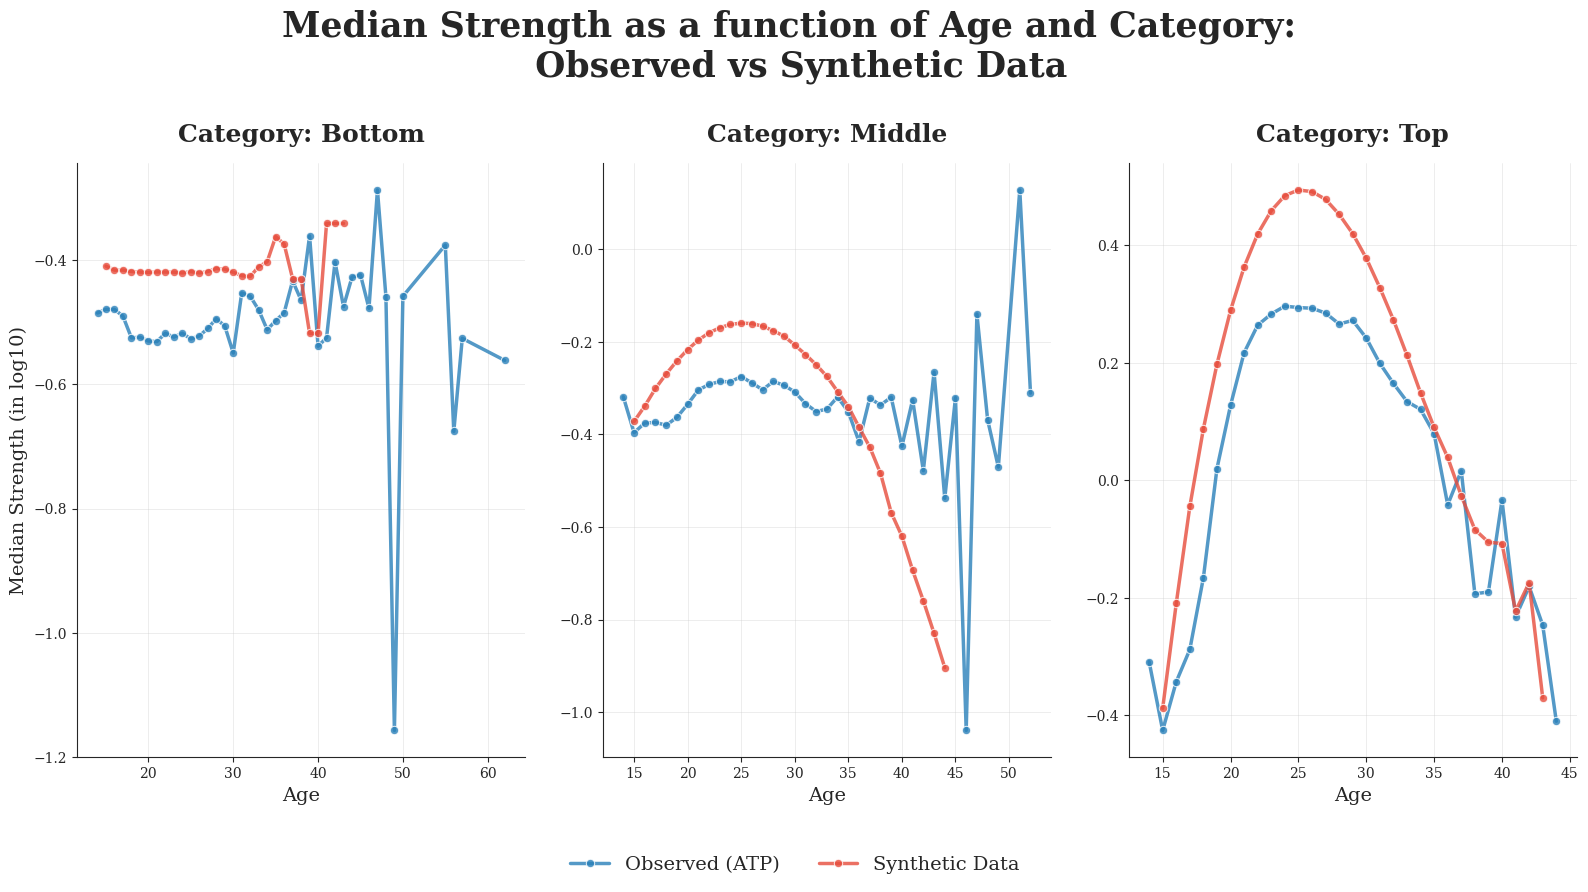

In [22]:
# Plot of the median strength value for each age and category

fig = plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})

for i, category in enumerate(aging_curve_choices):

    plt.subplot(1,3, i+1)

    observed_data_plot = observed_strengths_median_by_age.loc[category]
    synthetic_data_plot = synthetic_strengths_median_by_age.loc[category]

    sns.lineplot(x=observed_data_plot.index, y=observed_data_plot.values, 
                color="#2980b9", linewidth=2.5, 
                marker="o", markersize=6, alpha=0.8,
                label="Observed (ATP)", zorder=2, legend=False)
    
    sns.lineplot(x=synthetic_data_plot.index, y=synthetic_data_plot.values, 
                color="#e74c3c", linewidth=2.5, 
                marker="o", markersize=6, alpha=0.8,
                label="Synthetic Data", zorder=2, legend=False)
    
    plt.title(f"Category: {category.capitalize()}", fontsize=18, weight="bold", pad=15)
    plt.xlabel("Age", fontsize=14)

    if i == 0:
        plt.ylabel("Median Strength (in log10)", fontsize=14)
    else:
        plt.ylabel(" ")

    
    plt.xlabel(r"Age", fontsize=14) 

    
    plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor = (0.5, 0.02), fontsize=14, frameon=False)
plt.suptitle("Median Strength as a function of Age and Category: \n Observed vs Synthetic Data", fontsize=25, weight="bold", y=1.)    
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)
sns.despine()
plt.tight_layout(rect=[0, 0.1, 1, 0.99])
plt.show()

For the top players, the curve looks great, with a peak at around 26-28. The red simulated curve is slightly higher than the blue one, meaning that the dsitribution of the maximum strengths generates players who are a bit too strong compared to the actual median.

For the middle players, the observations are the same as for the top players at the beginning of the curve (ages 18-38). But then, the drop in the red curve is not similar to the blue curve anymore. In real life, an average player retires at the age of 35 (no more money, losses too much matches). In my simulation, the probability of retirement is based only on the age. It forces some players to keep playing, which drags the median down. It is not the case for the observed results because the players would retire and only the one with more talent continue.


The red curve of the botttom players is almost flat. This validates my model where this category of players has a constant strength, without any evolution. There is a small offset with the observed median.

The current model captures the overall dynamics, even though it doesn't reproduce exactly the same results.

As observed, the synthetic data does not perfectly overlap with the ATP data. But the core of players' evolution is well captured. There is a slight vertical offset between the simulated and observed curves. However, this absolute difference does not impact the simulaton, as the games results rely on the BT model, which is invariant under multiplication of a positive constant. 